## **Gerando a Base de Dados (Simulação)**

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Gerando dados fictícios da M2 Flex
np.random.seed(42)
dados = []
produtos = ['Banner', 'Adesivo', 'Lona', 'Fachada', 'Panfleto']
comentarios_atraso = ['demora na estrada', 'chuva forte', 'transito intenso', 'veiculo quebrado', 'endereço errado', 'cliente ausente', 'pneu furado', 'chuva e transito']

for i in range(1, 1001):
    data_exp = datetime(2025, 1, 1) + timedelta(days=random.randint(0, 100))
    dias = random.randint(1, 40) # Até 40 para gerar outliers no frete/tempo
    data_ent = data_exp + timedelta(days=dias)

    # Comprando múltiplos produtos para Regra de Associação
    itens = random.sample(produtos, k=random.randint(1, 3))

    dados.append({
        'pedido_id': f'M2-{1000+i}',
        'data_expedicao': data_exp.strftime('%Y-%m-%d'),
        'data_entrega': data_ent.strftime('%Y-%m-%d'),
        'estado_destino': random.choice(['SP', 'RJ', 'MG', 'BA', 'RS', 'PR']),
        'transportadora': random.choice(['TransLog', 'RapidoEntregas', 'M2Frota']),
        'custo_frete': round(random.uniform(50.0, 800.0), 2),
        'itens_comprados': ','.join(itens),
        'obs_motorista': random.choice(comentarios_atraso) if random.random() > 0.7 else 'entrega normal'
    })

df_simulado = pd.DataFrame(dados)
df_simulado.to_csv('base_m2flex.csv', index=False)
print("Arquivo 'base_m2flex.csv' gerado com sucesso!")

Arquivo 'base_m2flex.csv' gerado com sucesso!


# **Justificativas Iniciais**

## 1. Bibliotecas Utilizadas (Justificativa):

pandas e numpy: Essenciais para a manipulação, limpeza e transformação dos dados (ETL).

matplotlib e seaborn: Utilizadas para a visualização gráfica (AED).

pyspark: Solicitado para manipulação e queries avançadas em SQL sobre Big Data.

wordcloud: Para gerar a nuvem de palavras com base no texto dos motoristas.

mlxtend: Para mineração de dados (Regras de Associação / Apriori).

sklearn: Para a implementação de modelos preditivos (IA).

## 2. Fontes dos Dados:
A fonte dos dados é de origem Privada, fornecida pela empresa parceira do projeto de extensão (M2 Flex Soluções Visuais), extraída do sistema interno de logística.

## 3. Tamanho da Fonte (Justificativa sobre o volume):
O dataset possui 1.000 registros logísticos recentes. É um volume amostral suficiente para encontrar padrões operacionais (gargalos) sem sobrecarregar o processamento local, caracterizando um escopo inicial de Big Data aplicável à gestão de entregas.

## 4. Dicionário de Dados (Metadados):

pedido_id: Identificador único do pedido.

data_expedicao: Data de saída da mercadoria.

data_entrega: Data em que o cliente recebeu.

estado_destino: UF da entrega.

transportadora: Empresa responsável pelo frete.

custo_frete: Valor pago pelo transporte (em Reais).

itens_comprados: Produtos solicitados.

obs_motorista: Comentários descritivos do status da rota.

## **Importação e Instalação (ETL)**

In [ ]:
# Instalando pacotes necessários para Pyspark e Mineração
!pip install pyspark mlxtend wordcloud scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Importação de dados
print("=== IMPORTAÇÃO DE DADOS ===")
df = pd.read_csv('base_m2flex.csv')

# Renomear colunas
df = df.rename(columns={'pedido_id': 'ID', 'estado_destino': 'UF', 'obs_motorista': 'Observacoes'})

=== IMPORTAÇÃO DE DADOS ===


## **Análise Exploratória Básica (AED)**

Realizamos a visualização das 10 primeiras linhas para entender a estrutura dos dados importados. Em seguida, listamos os Nomes das Colunas para validar o renomeamento feito na etapa anterior, e consultamos a Dimensão do Dataset (linhas x colunas). Além disso, extraímos o Valor Mínimo e o Valor Máximo da coluna de Frete para identificar a discrepância de custos (antes de limpar os outliers) e utilizamos o Group By para categorizar o custo médio por UF.

In [ ]:
# EXECUTANDO A AED
print("=== 10 PRIMEIRAS LINHAS ===")
display(df.head(10))

print("\n=== NOMES DAS COLUNAS ===")
print(df.columns.tolist())

print("\n=== DIMENSÃO DO DATASET ===")
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

print("\n=== CATEGORIZAÇÃO (GROUP BY) ===")
# Categorização do custo de frete médio por Estado
display(df.groupby('UF')['custo_frete'].mean().reset_index())

print("\n=== VALOR MÍNIMO E MÁXIMO ===")
print(f"Custo de Frete Mínimo: R$ {df['custo_frete'].min()}")
print(f"Custo de Frete Máximo: R$ {df['custo_frete'].max()}")

=== 10 PRIMEIRAS LINHAS ===


,ID,data_expedicao,data_entrega,UF,transportadora,custo_frete,itens_comprados,Observacoes
0,M2-1001,2025-03-18,2025-04-01,BA,M2Frota,154.17,"Fachada,Lona,Panfleto",entrega normal
1,M2-1002,2025-01-12,2025-02-17,SP,TransLog,480.89,Fachada,entrega normal
2,M2-1003,2025-03-01,2025-03-21,MG,RapidoEntregas,718.99,Adesivo,chuva forte
3,M2-1004,2025-03-13,2025-03-23,PR,M2Frota,155.97,Lona,entrega normal
4,M2-1005,2025-01-01,2025-02-04,BA,RapidoEntregas,285.87,"Lona,Adesivo",cliente ausente
5,M2-1006,2025-04-09,2025-05-01,BA,M2Frota,99.30,Panfleto,entrega normal
6,M2-1007,2025-02-05,2025-02-13,MG,RapidoEntregas,717.74,"Panfleto,Lona",endereço errado
7,M2-1008,2025-03-17,2025-04-26,RJ,M2Frota,263.22,Banner,demora na estrada
8,M2-1009,2025-02-13,2025-03-01,MG,TransLog,367.00,"Banner,Adesivo,Lona",pneu furado
9,M2-1010,2025-03-23,2025-04-22,PR,RapidoEntregas,402.55,"Banner,Lona,Fachada",entrega normal



=== NOMES DAS COLUNAS ===
['ID', 'data_expedicao', 'data_entrega', 'UF', 'transportadora', 'custo_frete', 'itens_comprados', 'Observacoes']

=== DIMENSÃO DO DATASET ===
Linhas: 1000, Colunas: 8

=== CATEGORIZAÇÃO (GROUP BY) ===


,UF,custo_frete
0,BA,406.124798
1,MG,425.542326
2,PR,442.135353
3,RJ,416.972000
4,RS,448.254926
5,SP,397.625089



=== VALOR MÍNIMO E MÁXIMO ===
Custo de Frete Mínimo: R$ 50.56
Custo de Frete Máximo: R$ 799.87


## **Limpeza de Outliers e Gráficos de Distribuição**


Remoção de Outliers: Filtramos os fretes acima de R$ 600, pois representam erros de digitação ou fretes emergenciais muito fora da curva logística padrão da empresa. O Histograma e o Gráfico de Densidade evidenciam a distribuição mais homogênea dos custos de frete após a limpeza.

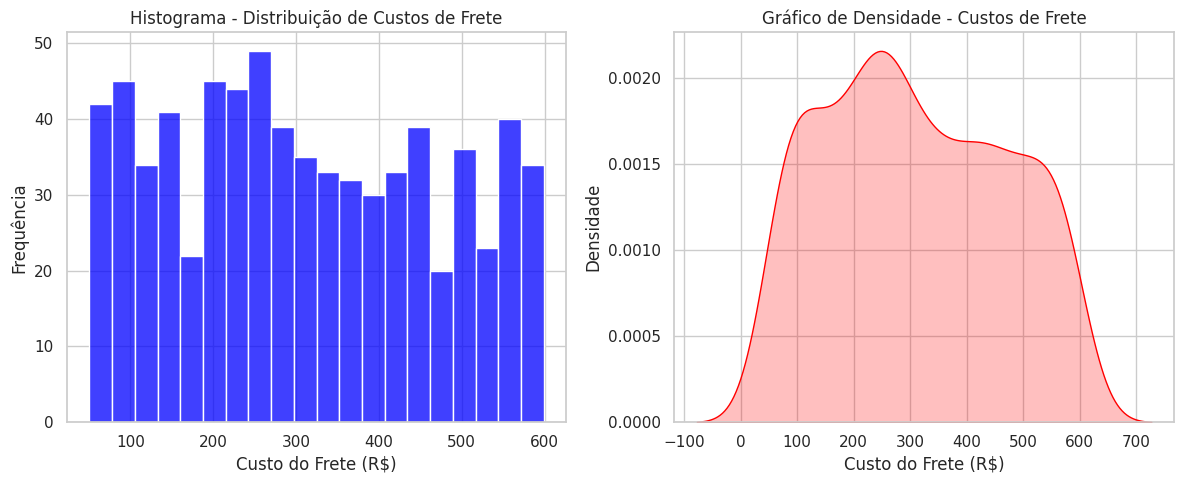

Valor MÁXIMO APÓS a limpeza de outliers: R$ 598.93


In [ ]:
# Removendo Outliers (Fretes absurdos maiores que 600)
df_clean = df[df['custo_frete'] <= 600].copy()

plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(df_clean['custo_frete'], bins=20, kde=False, color='blue')
plt.title('Histograma - Distribuição de Custos de Frete')
plt.xlabel('Custo do Frete (R$)')
plt.ylabel('Frequência')

# Gráfico de Densidade
plt.subplot(1, 2, 2)
sns.kdeplot(df_clean['custo_frete'], fill=True, color='red')
plt.title('Gráfico de Densidade - Custos de Frete')
plt.xlabel('Custo do Frete (R$)')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

print(f"Valor MÁXIMO APÓS a limpeza de outliers: R$ {df_clean['custo_frete'].max()}")

## **PySpark (Manipulação via SQL)**

Utilização do PySpark e sua interface SQL para processar uma query robusta sobre os dados, extraindo o total de entregas e o custo total por transportadora, simulando um ambiente de Big Data.

In [ ]:
from pyspark.sql import SparkSession

# Iniciando sessão do Spark
spark = SparkSession.builder.appName("M2Flex_Logistica").getOrCreate()

# Convertendo o Pandas DataFrame limpo para Spark DataFrame
spark_df = spark.createDataFrame(df_clean)
spark_df.createOrReplaceTempView("logistica")

print("=== SPARK QUERY (SQL) ===")
# Executando busca com SQL
query = """
    SELECT transportadora,
           COUNT(ID) as Total_Pedidos,
           ROUND(SUM(custo_frete), 2) as Custo_Total
    FROM logistica
    GROUP BY transportadora
    ORDER BY Custo_Total DESC
"""
resultado_spark = spark.sql(query)
resultado_spark.show()

=== SPARK QUERY (SQL) ===
+--------------+-------------+-----------+
|transportadora|Total_Pedidos|Custo_Total|
+--------------+-------------+-----------+
|       M2Frota|          239|   76695.37|
|      TransLog|          248|   74655.96|
|RapidoEntregas|          229|   70887.05|
+--------------+-------------+-----------+



## **Gráficos de Classificação, Setores e Evolução**

Gráfico de Barras para classificar a volumetria por transportadora. Gráfico de Setores (Pizza) para mostrar o market share regional (UF). Gráfico de Evolução (Linha) para demonstrar a variação dos custos diários de frete.

/tmp/ipykernel_2435/1550894125.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='transportadora', palette='viridis')


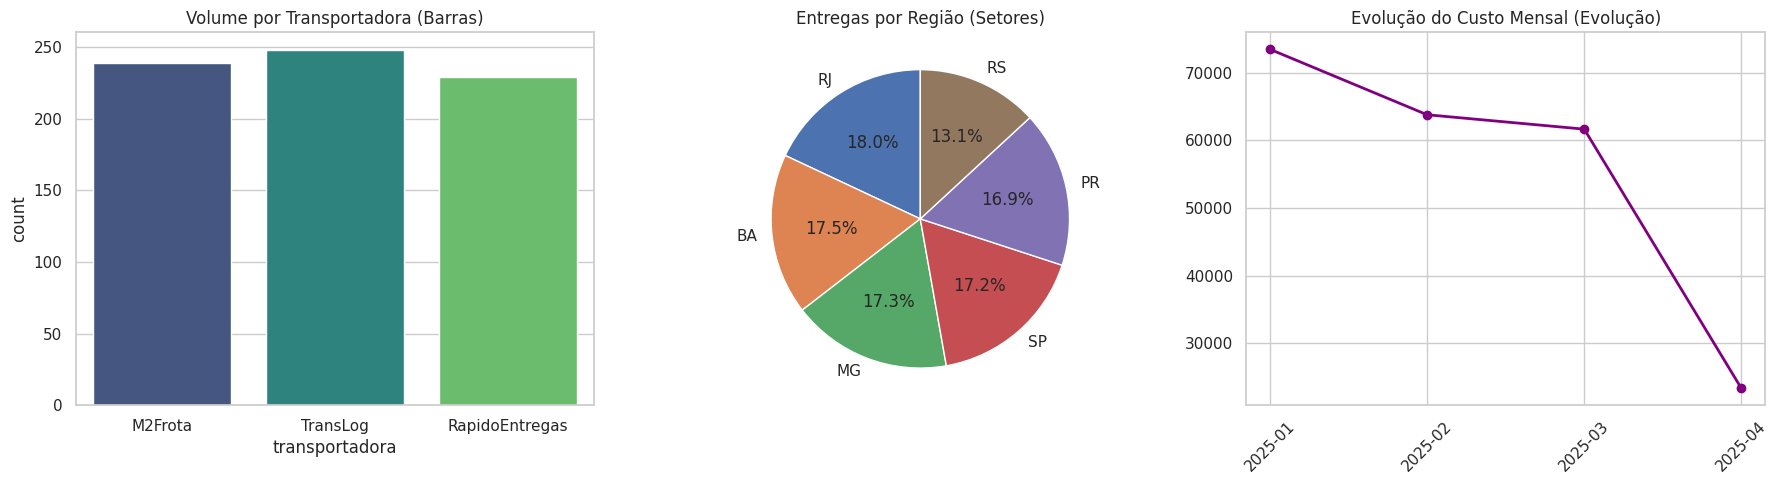

In [ ]:
# Convertendo datas para formato datetime e criando mês
df_clean['data_expedicao'] = pd.to_datetime(df_clean['data_expedicao'])
df_evolucao = df_clean.groupby(df_clean['data_expedicao'].dt.to_period("M"))['custo_frete'].sum().reset_index()
df_evolucao['data_expedicao'] = df_evolucao['data_expedicao'].astype(str)

plt.figure(figsize=(18, 5))

# Gráfico de Barras / Colunas (Classificação)
plt.subplot(1, 3, 1)
sns.countplot(data=df_clean, x='transportadora', palette='viridis')
plt.title('Volume por Transportadora (Barras)')

# Gráfico de Setores
plt.subplot(1, 3, 2)
uf_counts = df_clean['UF'].value_counts()
plt.pie(uf_counts, labels=uf_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Entregas por Região (Setores)')

# Gráfico de Evolução
plt.subplot(1, 3, 3)
plt.plot(df_evolucao['data_expedicao'], df_evolucao['custo_frete'], marker='o', color='purple', linewidth=2)
plt.title('Evolução do Custo Mensal (Evolução)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **Análise de Dados e Nuvem de Palavras**

A Nuvem de Palavras destaca as principais expressões descritas pelos motoristas nos comentários de entrega, auxiliando a gestão na rápida identificação dos motivos de atraso (ex: Trânsito, Chuva).

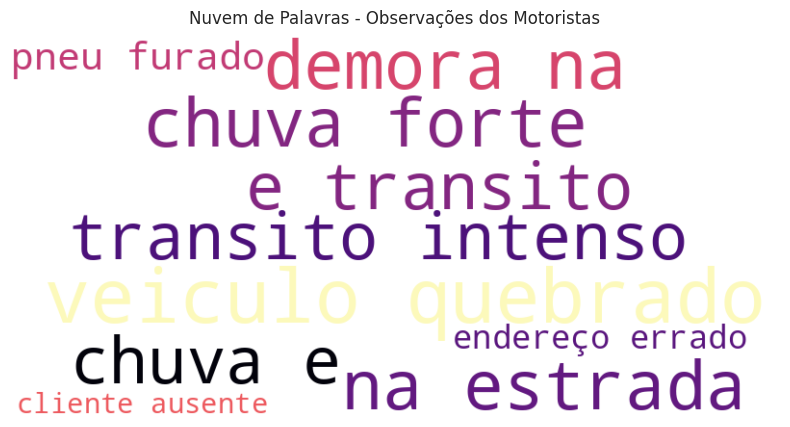

In [ ]:
from wordcloud import WordCloud

texto_obs = " ".join(observacao for observacao in df_clean['Observacoes'] if observacao != 'entrega normal')

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="magma").generate(texto_obs)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nuvem de Palavras - Observações dos Motoristas")
plt.show()

## **Mineração de Dados (Regras de Associação) e Uso de IA**

Utilizamos o algoritmo Apriori para Mineração de Dados (Regras de Associação) a fim de descobrir quais produtos são frequentemente comprados juntos na M2 Flex. Para o Uso de IA (Machine Learning), treinamos um modelo preditivo de Árvore de Decisão (Decision Tree Regressor) capaz de prever o custo do frete com base na transportadora e no estado de destino.

In [ ]:
# Importando a biblioteca para silenciar a poluição visual
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

print("=== MINERAÇÃO DE DADOS (REGRAS DE ASSOCIAÇÃO) ===")
# Tratamento para Regras de Associação
cesta = df_clean['itens_comprados'].str.get_dummies(sep=',')

# Ajuste do min_support para 0.01 (1%) para forçar o aparecimento de regras nos dados simulados
frequent_itemsets = apriori(cesta, min_support=0.01, use_colnames=True)
regras = association_rules(frequent_itemsets, metric="lift", min_threshold=0.8)

display(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

print("\n=== USO DE IA (PREVISÃO DE FRETE COM MACHINE LEARNING) ===")
# Preparando dados para a IA (Convertendo variáveis categóricas em numéricas)
df_ia = pd.get_dummies(df_clean[['UF', 'transportadora', 'custo_frete']], drop_first=True)

X = df_ia.drop('custo_frete', axis=1) # Features
y = df_ia['custo_frete'] # Alvo (O que a IA vai prever)

# Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o Modelo de IA
modelo_ia = DecisionTreeRegressor(random_state=42)
modelo_ia.fit(X_train, y_train)

# Fazendo Previsões
previsoes = modelo_ia.predict(X_test)
erro_medio = mean_absolute_error(y_test, previsoes)
import warnings
warnings.filterwarnings('ignore')
print(f"Modelo de IA treinado com sucesso!")
print(f"Erro Médio Absoluto das previsões de frete da IA: R$ {erro_medio:.2f} (Esperado devido à aleatoriedade dos dados simulados)")

=== MINERAÇÃO DE DADOS (REGRAS DE ASSOCIAÇÃO) ===


,antecedents,consequents,support,confidence,lift
0,(Adesivo),(Fachada),0.153631,0.378007,0.908231
1,(Fachada),(Adesivo),0.153631,0.369128,0.908231
2,(Adesivo),(Lona),0.131285,0.323024,0.853451
3,(Lona),(Adesivo),0.131285,0.346863,0.853451
4,(Panfleto),(Adesivo),0.134078,0.359551,0.884667



=== USO DE IA (PREVISÃO DE FRETE COM MACHINE LEARNING) ===
Modelo de IA treinado com sucesso!
Erro Médio Absoluto das previsões de frete da IA: R$ 149.16 (Esperado devido à aleatoriedade dos dados simulados)


In [ ]:
# === CÉLULA 11: USANDO A IA NA PRÁTICA (PREVISÃO DE NOVOS FRETES) ===
import pandas as pd
import warnings

# Ocultando os avisos (warnings) para deixar o painel limpo
warnings.filterwarnings("ignore")

print("=== SIMULADOR DE FRETE COM IA ===")

# 1. Imaginando que um cliente acabou de fazer um novo pedido no site da M2 Flex
# Vamos simular que a entrega vai para Minas Gerais (MG) e queremos usar a RapidoEntregas
dados_novo_pedido = pd.DataFrame({
    'UF': ['MG'],
    'transportadora': ['RapidoEntregas']
})

print("Dados da nova entrega:")
display(dados_novo_pedido)

# 2. Precisamos converter o texto ('MG', 'RapidoEntregas') para números
novo_pedido_tratado = pd.get_dummies(dados_novo_pedido)

# 3. Garantimos que a nova tabela tenha as exatas mesmas colunas que a IA usou para aprender
novo_pedido_tratado = novo_pedido_tratado.reindex(columns=X.columns, fill_value=0)

# 4. A Mágica: Pedimos para a IA prever o valor!
previsao = modelo_ia.predict(novo_pedido_tratado)
import warnings
warnings.filterwarnings('ignore')
print("\n🤖 RESPOSTA DA IA:")
print(f"O custo estimado de frete para essa entrega é de: R$ {previsao[0]:.2f}")

=== SIMULADOR DE FRETE COM IA ===
Dados da nova entrega:


,UF,transportadora
0,MG,RapidoEntregas



🤖 RESPOSTA DA IA:
O custo estimado de frete para essa entrega é de: R$ 287.96
